In [ ]:
!pip install qiskit
!pip install qiskit-ibm-runtime
!pip install matplotlib
!pip install pandas
!pip install scikit-learn

In [1]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import QFT
from qiskit.quantum_info import Statevector, partial_trace
import numpy as np

## Fundamental Auxiliary Operators Circuit 

Inputs: n:3 a:3 k:3


C:\Users\tsahu\AppData\Local\Temp\ipykernel_25512\101378740.py:16: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n, do_swaps=True,), range(n))
C:\Users\tsahu\AppData\Local\Temp\ipykernel_25512\101378740.py:23: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n, do_swaps=True,).inverse(), range(n))


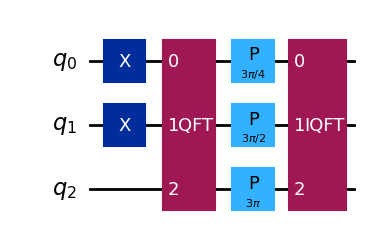

In [190]:
# Parameters

n = 3             
a = 3    
k = 3

print(f'Inputs: n:{n} a:{a} k:{k}')

qc = QuantumCircuit(n)

for i in range(n):
    if (a >> i) & 1:
        qc.x(i)


qc.append(QFT(n, do_swaps=True,), range(n))

for i in range(n):
    angle = (2 * np.pi * k) / (2 ** (n - i))
    qc.p(angle, i)


qc.append(QFT(n, do_swaps=True,).inverse(), range(n))


qc.draw('mpl')

In [191]:
state = Statevector(qc)
state.draw('latex')

<IPython.core.display.Latex object>

## Inplace Modular Quantum-Classical Adder Circuit

Inputs: n:3 a:3 k:4 N:5


C:\Users\tsahu\AppData\Local\Temp\ipykernel_25512\2985918830.py:20: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n + 1, do_swaps=True).to_gate(), range(1, n+2))
C:\Users\tsahu\AppData\Local\Temp\ipykernel_25512\2985918830.py:30: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n + 1, do_swaps=True).inverse().to_gate(), range(1, n+2))
C:\Users\tsahu\AppData\Local\Temp\ipykernel_25512\2985918830.py:41: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will 

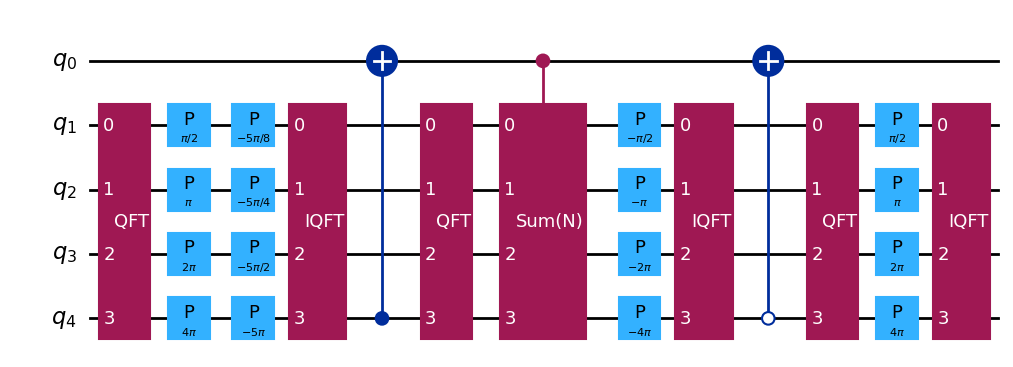

In [203]:
k = 4
n = 3
N = 5
a = 3

def addin_cir(n, k, N):
    sumbit = n + 1
    qc = QuantumCircuit(n + 2)
    sumN = QuantumCircuit(n + 1, name="Sum(N)")
    aux_q1 = n 
    aux_q2 = n + 1

    '''
    Part 1: 
    First is the QFT
    Next the rotations are applied which are Sum(k) and Sum(-N) 
    Next the QFT Inverse is applied
    Last a CNOT is being applied to the auxiliary wire
    '''
    qc.append(QFT(n + 1, do_swaps=True).to_gate(), range(1, n+2))

    for i in range(n + 1):
        angle = (2 * np.pi * k) / (2 ** (sumbit - i))
        qc.p(angle, i+1)

    for i in range(n + 1):
        angle = (2 * np.pi * (-N)) / (2 ** (sumbit - i))
        qc.p(angle, i+1)

    qc.append(QFT(n + 1, do_swaps=True).inverse().to_gate(), range(1, n+2))

    qc.cx(aux_q2, 0)

    '''
    Part 2: 
    The QFT is applied
    Next the rotations are applied which are Sum(N), which has a control on the auxiliary wire, and Sum(-N) 
    Then the QFT Inverse is applied
    '''

    qc.append(QFT(n + 1, do_swaps=True).to_gate(), range(1, n+2))

    for i in range(n + 1):
        angle = (2 * np.pi * (N)) / (2 ** (sumbit - i))
        sumN.p(angle, i)

    qc.append(sumN.to_gate().control(1), [0] + list(range(1, n+2)))

    for i in range(n + 1):
        angle = (2 * np.pi * (-k)) / (2 ** (sumbit - i))
        qc.p(angle, i+1)

    qc.append(QFT(n + 1, do_swaps=True).inverse().to_gate(), range(1, n+2))

    '''
    Part 3: 
    A CNOT gate is applied with a control state of 0
    The QFT is applied
    Next the rotations are applied which are Sum(N), which has a control on the auxiliary wire, and Sum(-N) 
    Then the QFT Inverse is applied to the auxiliary
    Returned is the Quantum Circuit
    '''

    qc.cx(aux_q2, 0, ctrl_state=0)

    qc.append(QFT(n + 1, do_swaps=True).to_gate(), range(1, n+2))

    for i in range(n + 1):
        angle = (2 * np.pi * (k)) / (2 ** (sumbit - i))
        qc.p(angle, i+1)

    qc.append(QFT(n + 1, do_swaps=True).inverse().to_gate(), range(1, n+2))


    return qc

print(f'Inputs: n:{n} a:{a} k:{k} N:{N}')

# Testing the Circuit

test_qc_IMQCA = QuantumCircuit(n+2)

drawqc = addin_cir(n, k, N).to_gate()

for i in range(n):     # a value using x gates
    if (a >> i) & 1:
        test_qc_IMQCA.x(i+1)

test_qc_IMQCA.append(drawqc, range(n+2))

addin_cir(n, k, N).draw('mpl')


In [204]:
print("The middle 3 bits is |a + k mod N>")
state = Statevector(test_qc_IMQCA)
state.draw('latex')

The middle 3 bits is |a + k mod N>


<IPython.core.display.Latex object>

## Outplace Modular Quantum-Classical Adder Circuit

Inputs: n:3 a:3 k:4 N:5


C:\Users\tsahu\AppData\Local\Temp\ipykernel_25512\2985918830.py:20: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n + 1, do_swaps=True).to_gate(), range(1, n+2))
C:\Users\tsahu\AppData\Local\Temp\ipykernel_25512\2985918830.py:30: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n + 1, do_swaps=True).inverse().to_gate(), range(1, n+2))
C:\Users\tsahu\AppData\Local\Temp\ipykernel_25512\2985918830.py:41: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will 

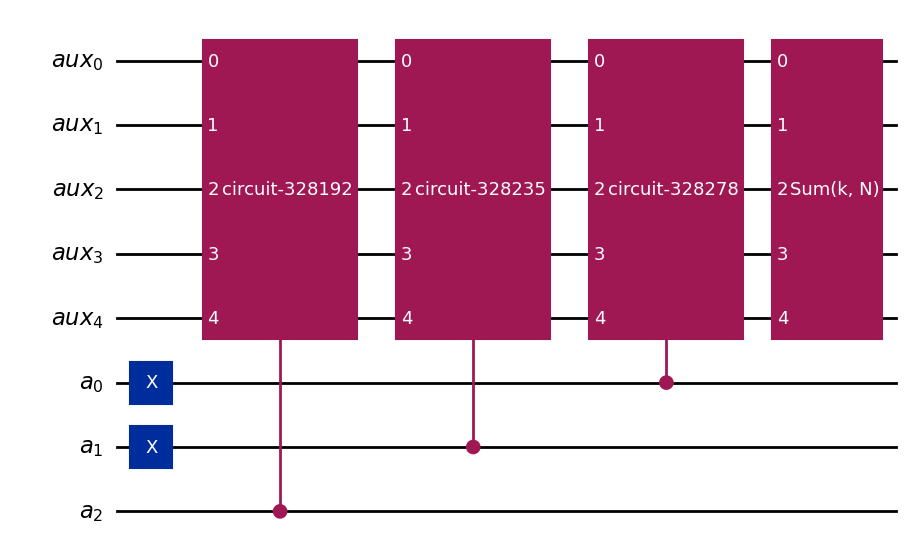

In [205]:
k = 4
n = 3
N = 5
a = 3
def OMQCA_cir(n, k, a, N):

    # Here we create the Quantum Registers to go into the Quantum Circuit
    qc_a = QuantumRegister(n, name='a')
    qc_aux = QuantumRegister(n + 2, name='aux')
    qc = QuantumCircuit(qc_aux, qc_a)
    totl_qubits = len(qc_a) + len(qc_aux) - 1 # total qubits from 0
    
    # This applies the input to the circuit
    for i in range(n):     # a value using x gates
            if (a >> i) & 1:
                qc.x(qc_a[i])

    '''
    This takes the Addin Circuit made previously and applies them based on the amount of input qubits
    A control is added to each of the circuits going down an input each time
    The tempk is used for the 2 ** n values
    '''
    for i in range(n):
        tempk = 2 ** (n-(i+1))
        addin = addin_cir(n, tempk, N).to_gate().control(1)
        addin.name = f'Addin({tempk})'
        qc.append(addin, [totl_qubits - i] + qc_aux[:])

    # Final part of the Quantum Circuit is to use the Addin circuit with k and N
    addin_kN = addin_cir(n, k, N)
    addin_kN.name = 'Sum(k, N)'
    qc.append(addin_kN, qc_aux[:])

    return qc

print(f'Inputs: n:{n} a:{a} k:{k} N:{N}')

drawqc_OMQCA = OMQCA_cir(n, k, a, N)
drawqc_OMQCA.draw('mpl')

In [206]:
print("bits 4,5,6 are |a + k mod N>")
state = Statevector(drawqc_OMQCA)
state.draw('latex')

bits 4,5,6 are |a + k mod N>


<IPython.core.display.Latex object>

## Inplace Modular Quantum-Quantum Adder Circuit

Inputs: n:3 a:2 b:2 N:5


C:\Users\tsahu\AppData\Local\Temp\ipykernel_25512\2985918830.py:20: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n + 1, do_swaps=True).to_gate(), range(1, n+2))
C:\Users\tsahu\AppData\Local\Temp\ipykernel_25512\2985918830.py:30: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n + 1, do_swaps=True).inverse().to_gate(), range(1, n+2))
C:\Users\tsahu\AppData\Local\Temp\ipykernel_25512\2985918830.py:41: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will 

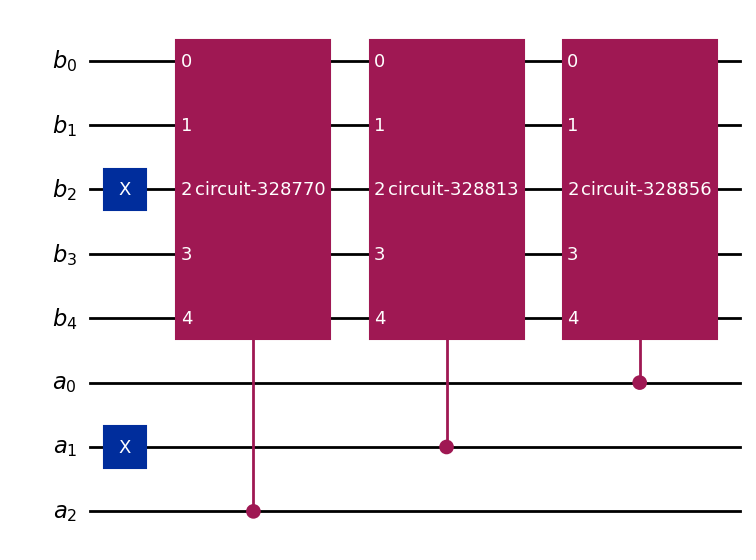

In [207]:
n = 3
N = 5
a = 2
b = 2
def IMQQA_cir(n, b, a, N):

    ''' 
    Here we create the Quantum Registers to go into the Quantum Circuit
    A variable totl_qubits is added to aid in applying the circuits
    '''
    qc_a = QuantumRegister(n, name='a')
    qc_b = QuantumRegister(n + 2, name='b')
    qc = QuantumCircuit(qc_b, qc_a)
    totl_qubits = len(qc_a) + len(qc_b) - 1 # total qubits from 0

    # These apply the inputs to the circuit
    for i in range(n):     # a value using x gates
            if (a >> i) & 1:
                qc.x(qc_a[i])

    for i in range(n):     # b value using x gates
            if (b >> i) & 1:
                qc.x(qc_b[i+1])

    '''
    This takes the Addin Circuit made previously and applies them based on the amount of input qubits
    A control is added to each of the circuits going down an input each time
    The tempk is used for the 2 ** n values
    '''
    for i in range(n):
        tempk = 2 ** (n-(i+1))
        addin = addin_cir(n, tempk, N).to_gate().control(1)
        addin.name = f'Addin({tempk})'
        qc.append(addin, [totl_qubits - i] + qc_b[:])

    return qc

print(f'Inputs: n:{n} a:{a} b:{b} N:{N}')

drawqc_IMQQA = IMQQA_cir(n, b, a, N)
drawqc_IMQQA.draw('mpl')

In [208]:
print("bits 4,5,6 are |a + b mod N>")
state = Statevector(drawqc_IMQQA)
state.draw('latex')

bits 4,5,6 are |a + b mod N>


<IPython.core.display.Latex object>

## Outplace Modular Quantum-Quantum Adder

Inputs: n:3 a:3 b:4 N:5


C:\Users\tsahu\AppData\Local\Temp\ipykernel_25512\2985918830.py:20: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n + 1, do_swaps=True).to_gate(), range(1, n+2))
C:\Users\tsahu\AppData\Local\Temp\ipykernel_25512\2985918830.py:30: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n + 1, do_swaps=True).inverse().to_gate(), range(1, n+2))
C:\Users\tsahu\AppData\Local\Temp\ipykernel_25512\2985918830.py:41: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will 

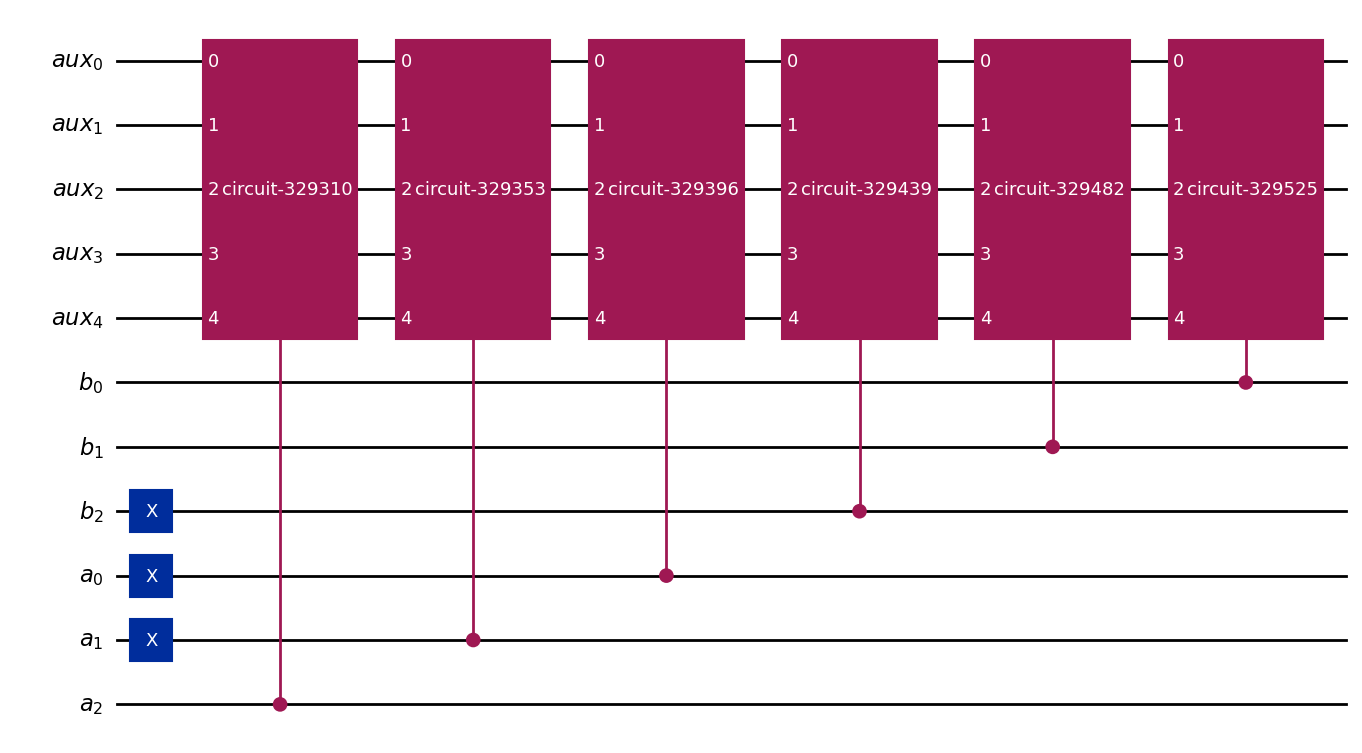

In [209]:
n = 3
N = 5
a = 3
b = 4

def OMQQA_cir(n, b, a, N):

    ''' 
    Here we create the Quantum Registers to go into the Quantum Circuit
    A variable totl_qubits is added to aid in applying the circuits
    '''
    qc_a = QuantumRegister(n, name='a')
    qc_b = QuantumRegister(n, name='b')
    qc_aux = QuantumRegister(n + 2, name='aux')
    qc = QuantumCircuit(qc_aux, qc_b, qc_a)
    totl_qubits = len(qc_a) + len(qc_b) + len(qc_aux) - 1 # total qubits from 0
    totl_qubits_list = list(range(totl_qubits + 1))

    # These apply the inputs to the circuit
    for i in range(n):     # a value using x gates
            if (a >> i) & 1:
                qc.x(qc_a[i])

    for i in range(n):     # b value using x gates
            if (b >> i) & 1:
                qc.x(qc_b[i])

    '''
    This takes the Addin Circuit made previously and applies them based on the amount of input qubits
    A control is added to each of the circuits going down an input each time
    One set of circuits is attached to the a input
    One set of circuits is attached to the b input
    The tempk is used for the 2 ** n values
    '''
    for i in range(n):
        tempk = 2 ** (n-(i+1))
        addin = addin_cir(n, tempk, N).to_gate().control(1)
        addin.name = f'Addin({tempk}, N)'
        qc.append(addin, [qc_a[n-(i+1)]] + qc_aux[:])

    for i in range(n):
        tempk = 2 ** (n-(i+1))
        addin = addin_cir(n, tempk, N).to_gate().control(1)
        addin.name = f'Addin({tempk}, N)'
        qc.append(addin, [qc_b[n-(i+1)]] + qc_aux[:])

    return qc

print(f'Inputs: n:{n} a:{a} b:{b} N:{N}')

drawqc_OMQQA = OMQQA_cir(n, b, a, N)
drawqc_OMQQA.draw('mpl')

In [210]:
print("bits 7,8,9 are |a + b mod N>")
state = Statevector(drawqc_OMQQA)
state.draw('latex')

bits 7,8,9 are |a + b mod N>


<IPython.core.display.Latex object>

## Outplace Modular Quantum-Classical Multiplier

Inputs: n:3 a:2 b:3 k:2 N:5


C:\Users\tsahu\AppData\Local\Temp\ipykernel_25512\2985918830.py:20: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n + 1, do_swaps=True).to_gate(), range(1, n+2))
C:\Users\tsahu\AppData\Local\Temp\ipykernel_25512\2985918830.py:30: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n + 1, do_swaps=True).inverse().to_gate(), range(1, n+2))
C:\Users\tsahu\AppData\Local\Temp\ipykernel_25512\2985918830.py:41: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will 

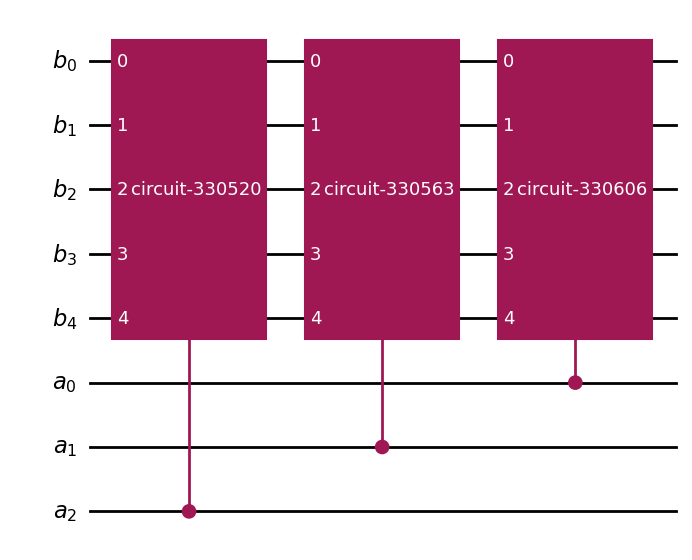

In [211]:
k = 2
a = 2
b = 3
n = 3
N = 5

def multout_cir(n, k, N):

    ''' 
    Here we create the Quantum Registers to go into the Quantum Circuit
    A variable totl_qubits is added to aid in applying the circuits
    '''
    qc_a = QuantumRegister(n, name='a')
    qc_b = QuantumRegister(n + 2, name='b')
    qc = QuantumCircuit(qc_b, qc_a)
    totl_qubits = len(qc_a) + len(qc_b) - 1 # total qubits from 0

    '''
    This takes the Addin Circuit made previously and applies them based on the amount of input qubits
    A control is added to each of the circuits going down an input each time
    The tempk is used for the 2 ** n values
    '''
    for i in range(n):
        tempk = (2 ** (n-(i+1))) * k
        addin = addin_cir(n, tempk, N).to_gate().control(1)
        addin.name = f'Addin({tempk})'
        qc.append(addin, [totl_qubits - i] + qc_b[:])

    return qc

print(f'Inputs: n:{n} a:{a} b:{b} k:{k} N:{N}')
    
# Testing the circuit
test_qc_OMQCM = QuantumCircuit(8)

# These apply the inputs to the circuit while testing
for i in range(n):     # a value using x gates
    if (a >> i) & 1:
        test_qc_OMQCM.x(5 + i)

for i in range(n):     # b value using x gates
        if (b >> i) & 1:
            test_qc_OMQCM.x(i+1)
        
drawqc = multout_cir(n, k, N).to_gate()
test_qc_OMQCM.append(drawqc, range(8))
        
multout_cir(n, k, N).draw('mpl')


In [212]:
print("bits 4,5,6 are |b + ka mod N>")
state = Statevector(test_qc_OMQCM)
state.draw('latex')

bits 4,5,6 are |b + ka mod N>


<IPython.core.display.Latex object>

## Inplace Modular Quantum-Classical Multiplier

Inputs: n:3 a:1 k:2 N:5


C:\Users\tsahu\AppData\Local\Temp\ipykernel_25512\2985918830.py:20: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n + 1, do_swaps=True).to_gate(), range(1, n+2))
C:\Users\tsahu\AppData\Local\Temp\ipykernel_25512\2985918830.py:30: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n + 1, do_swaps=True).inverse().to_gate(), range(1, n+2))
C:\Users\tsahu\AppData\Local\Temp\ipykernel_25512\2985918830.py:41: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will 

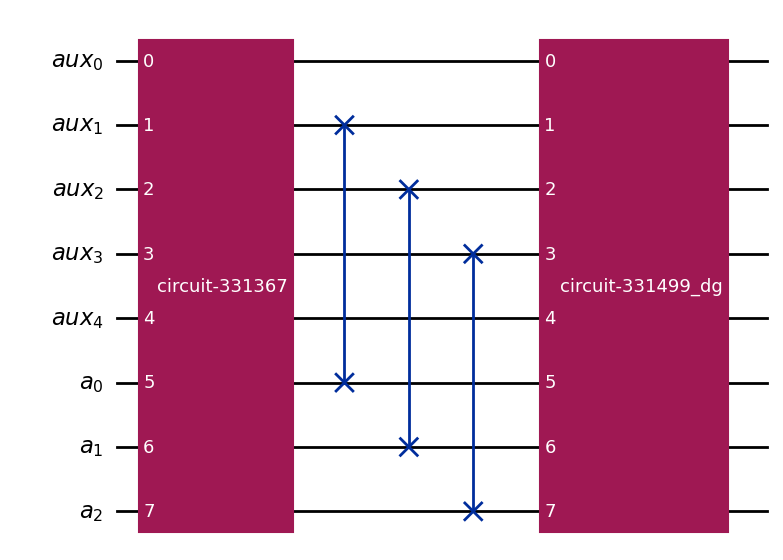

In [213]:
k = 2
a = 1
n = 3
N = 5

def IMQCM_cir(n, k, N):

    ''' 
    Here we create the Quantum Registers to go into the Quantum Circuit
    A variable totl_qubits is added to aid in applying the circuits
    '''
    qc_a = QuantumRegister(n, name='a')
    qc_aux = QuantumRegister(n + 2, name='aux')
    qc = QuantumCircuit(qc_aux, qc_a)
    totl_qubits = len(qc_a) + len(qc_aux) - 1 # total qubits from 0

    '''
    Creating and applying the Multout circuit
    '''
    multout = multout_cir(n, k, N).to_gate()
    qc.append(multout, range(totl_qubits + 1))

    '''
    Adding swap gates to swap the input values
    Creating and applying the inverse Multout Circuit
    '''
    for i in range(n):
        qc.swap(qc_a[i], qc_aux[i+1])

    multout2 = multout_cir(n, (k**(-1)), N).to_gate().inverse()
    qc.append(multout2, range(totl_qubits + 1))

    return qc

print(f'Inputs: n:{n} a:{a} k:{k} N:{N}')

# Testing the Circuit

test_qc_IMQCM = QuantumCircuit(8)

# This applies the inputs to the circuit while testing
for i in range(n):     # a value using x gates
    if (a >> i) & 1:
        test_qc_IMQCM.x(5 + i)
        
drawqc = IMQCM_cir(n, k, N).to_gate()
test_qc_IMQCM.append(drawqc, range(8))
        
IMQCM_cir(n, k, N).draw('mpl')


In [214]:
print("bits 0,1,2 are |ka mod N>")
state = Statevector(test_qc_IMQCM)
state.draw('latex')

bits 0,1,2 are |ka mod N>


<IPython.core.display.Latex object>

## Outplace Modular Quantum-Quantum Multiplier

Inputs: n:3 a:2 b:2 k:2 N:5


C:\Users\tsahu\AppData\Local\Temp\ipykernel_25512\2985918830.py:20: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n + 1, do_swaps=True).to_gate(), range(1, n+2))
C:\Users\tsahu\AppData\Local\Temp\ipykernel_25512\2985918830.py:30: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n + 1, do_swaps=True).inverse().to_gate(), range(1, n+2))
C:\Users\tsahu\AppData\Local\Temp\ipykernel_25512\2985918830.py:41: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will 

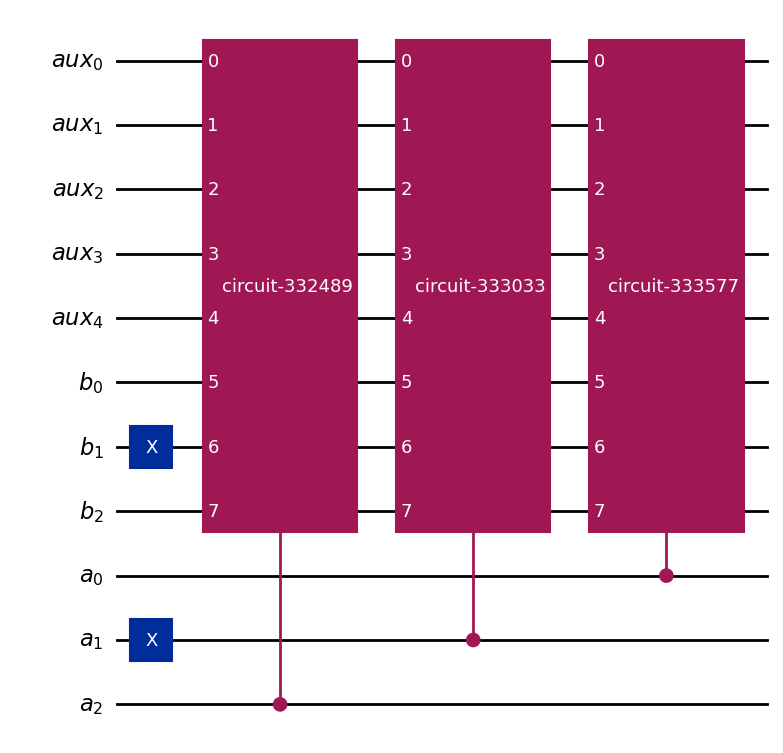

In [215]:
k = 2
a = 2
b = 2
n = 3
N = 5

def OMQQM_cir(n, a, b, k, N):

    ''' 
    Here we create the Quantum Registers to go into the Quantum Circuit
    A variable totl_qubits is added to aid in applying the circuits
    '''
    qc_a = QuantumRegister(n, name='a')
    qc_b = QuantumRegister(n, name='b')
    qc_aux = QuantumRegister(n + 2, name='aux')
    qc = QuantumCircuit(qc_aux, qc_b, qc_a)
    totl_qubits = len(qc_a) + len(qc_b) + len(qc_aux) - 1 # total qubits from 0

    # These apply the inputs to the circuit while testing
    for i in range(n):     # a value using x gates
        if (a >> i) & 1:
            qc.x(qc_a[i])

    for i in range(n):     # b value using x gates
        if (b >> i) & 1:
            qc.x(qc_b[i])

    '''
    This takes the Multout Circuit made previously and applies them based on the amount of input qubits
    A control is added to each of the circuits going down an input each time
    The tempk is used for the 2 ** n values
    '''
    for i in range(n):
        tempk = (2 ** (n-(i+1)))
        multin = multout_cir(n, tempk, N).to_gate().control(1)
        multin.name = f'Addin({tempk})'
        qc.append(multin, [totl_qubits - i] + qc_aux[:] + qc_b[:])

    return qc

print(f'Inputs: n:{n} a:{a} b:{b} k:{k} N:{N}')

drawqc_OMQQM = OMQQM_cir(n, a, b, k, N)
drawqc_OMQQM.draw('mpl') 

In [216]:
print("bits 7,8,9 are |ab mod N>")
state = Statevector(drawqc_OMQQM)
state.draw('latex')

bits 7,8,9 are |ab mod N>


<IPython.core.display.Latex object>

## Outplace Modular Exponential Operator

Inputs: n:3 a:2 x:2 N:7


C:\Users\tsahu\AppData\Local\Temp\ipykernel_25512\2985918830.py:20: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n + 1, do_swaps=True).to_gate(), range(1, n+2))
C:\Users\tsahu\AppData\Local\Temp\ipykernel_25512\2985918830.py:30: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n + 1, do_swaps=True).inverse().to_gate(), range(1, n+2))
C:\Users\tsahu\AppData\Local\Temp\ipykernel_25512\2985918830.py:41: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will 

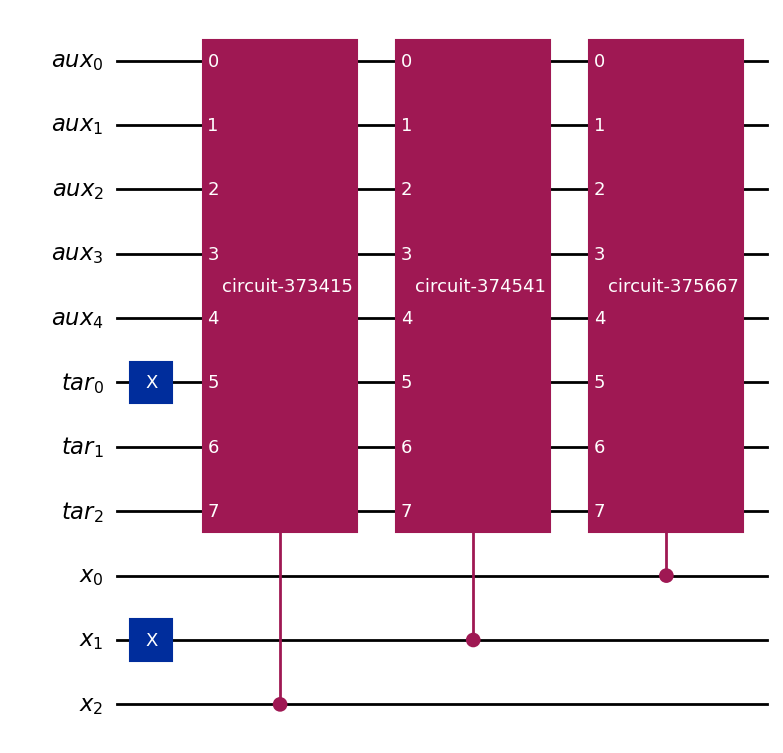

In [219]:
N = 7
n = 3
x = 2
a = 2

def OMEO_cir(n, x, a, N):

    ''' 
    Here we create the Quantum Registers to go into the Quantum Circuit
    A variable totl_qubits is added to aid in applying the circuits
    '''
    qc_x = QuantumRegister(n, name='x')
    qc_tar = QuantumRegister(n, name='tar')
    qc_aux = QuantumRegister(n + 2, name='aux')
    qc = QuantumCircuit(qc_aux, qc_tar, qc_x)
    totl_qubits = len(qc_x) + len(qc_tar) + len(qc_aux) - 1 # total qubits from 0

    # These apply the inputs to the circuit while testing
    for i in range(n):     # a value using x gates
        if (x >> i) & 1:
            qc.x(qc_x[i])

    for i in range(n): 
        if (1 >> i) & 1:
            qc.x(qc_tar[i])

    '''
    This takes the Multin Circuit made previously and applies them based on the amount of input qubits
    A control is added to each of the circuits going down an input each time
    The tempk is used for the a ** (2 ** n) values
    '''
    for i in range(n):
        tempk = (a ** (2 ** (n-(i+1))))
        multin = IMQCM_cir(n, tempk, N).to_gate().control(1)
        multin.name = f'Addin({tempk})'
        qc.append(multin, [totl_qubits - i] + qc_aux[:] + qc_tar[:])

    return qc

print(f'Inputs: n:{n} a:{a} x:{x} N:{N}')

drawqc_OMEO = OMEO_cir(n, x, a, N)
drawqc_OMEO.draw('mpl') 

In [218]:
print("bits 3,4,5 are |a^x mod N>")
state = Statevector(drawqc_OMEO)
state.draw('latex')

bits 3,4,5 are |a^x mod N>


<IPython.core.display.Latex object>